In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

life_ex = pd.read_csv('life-expectancy.csv')
poverty = pd.read_csv('share-of-population-living-in-extreme-poverty.csv')
econ_ineq = pd.read_csv('economic-inequality-gini-index.csv')
fertility = pd.read_csv('children-per-woman-un.csv')
sanitation = pd.read_csv('share-using-safely-managed-sanitation.csv')
height_w = pd.read_csv('average-height-of-women.csv')
height_m = pd.read_csv('average-height-of-men.csv')
earthquakes = pd.read_csv('earthquakes.csv')

In [2]:
# 'infant deaths', 'Alcohol', ' BMI ', 'GDP', 'Population'
life_ex.rename(columns={'Life expectancy ':'Life Expectancy',
                       ' BMI ':'BMI'}, inplace=True)

poverty.rename(columns={'Share below $2.15 a day':'Extreme Poverty'}, inplace=True)

econ_ineq.drop(columns=['990179-annotations'], inplace=True)
econ_ineq.rename(columns={'Gini coefficient':'Gini Coefficient',
                          'Entity':'Country'}, inplace=True)

fertility.rename(columns={'Entity':'Country',
                        "Fertility rate - Sex: all - Age: all - Variant: estimates": "Fertility Rate"}, inplace=True)

sanitation.rename(columns={"Share of the population using safely managed sanitation services": "Safe Sanitation",
                          'Entity':'Country'}, inplace=True)
sanitation.drop(columns=["Code"], inplace=True)
sanitation['Country'] = sanitation['Country'].str.replace(r' \(WHO\)$', '', regex=True)

## Data Exploration

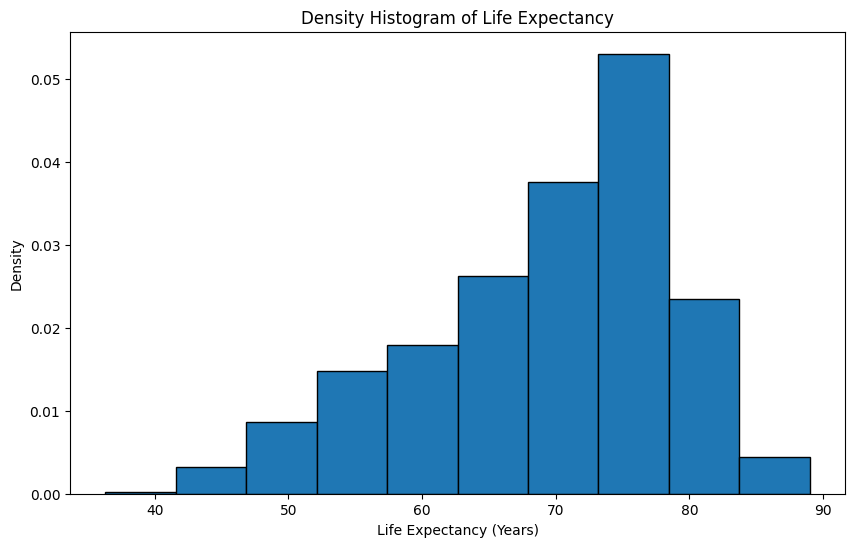

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(life_ex['Life Expectancy'], density=True, edgecolor='black')
plt.title('Density Histogram of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Density')
plt.show()

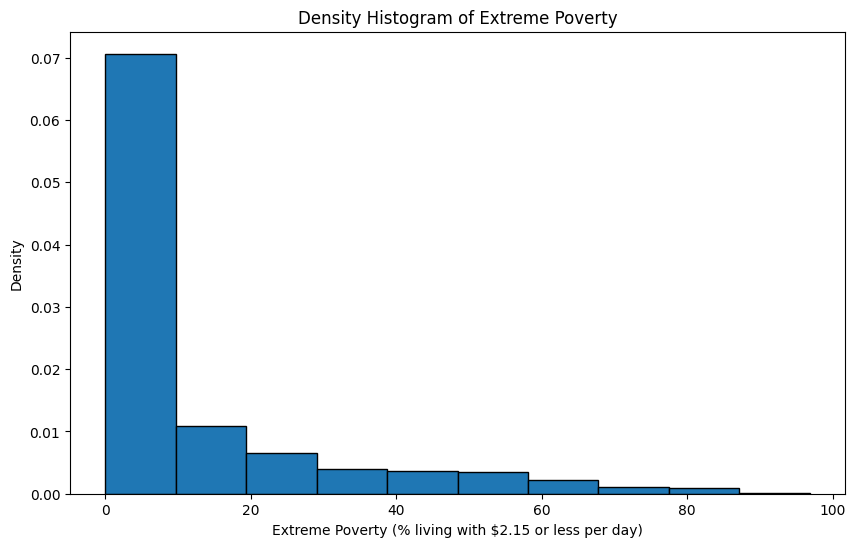

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(poverty['Extreme Poverty'], density=True, edgecolor='black')
plt.title('Density Histogram of Extreme Poverty')
plt.xlabel('Extreme Poverty (% living with $2.15 or less per day)')
plt.ylabel('Density')
plt.show()

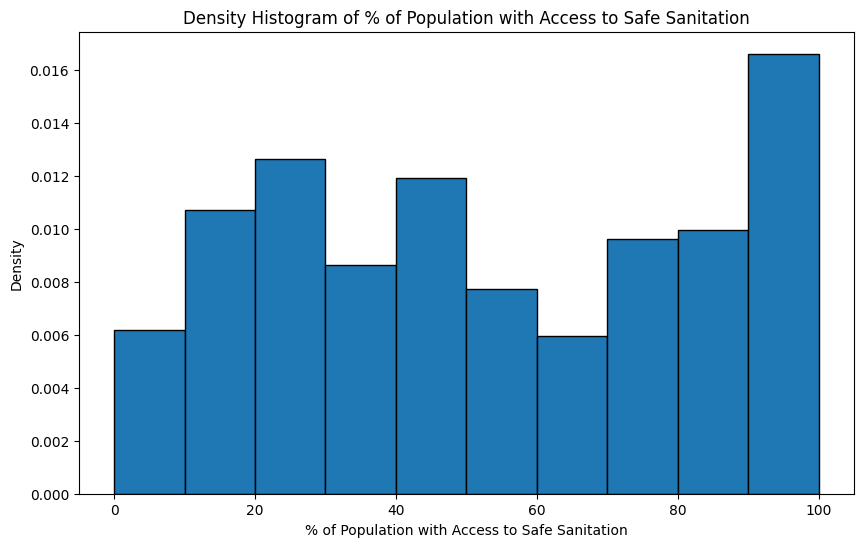

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(sanitation['Safe Sanitation'], density=True, edgecolor='black')
plt.title('Density Histogram of % of Population with Access to Safe Sanitation')
plt.xlabel('% of Population with Access to Safe Sanitation')
plt.ylabel('Density')
plt.show()

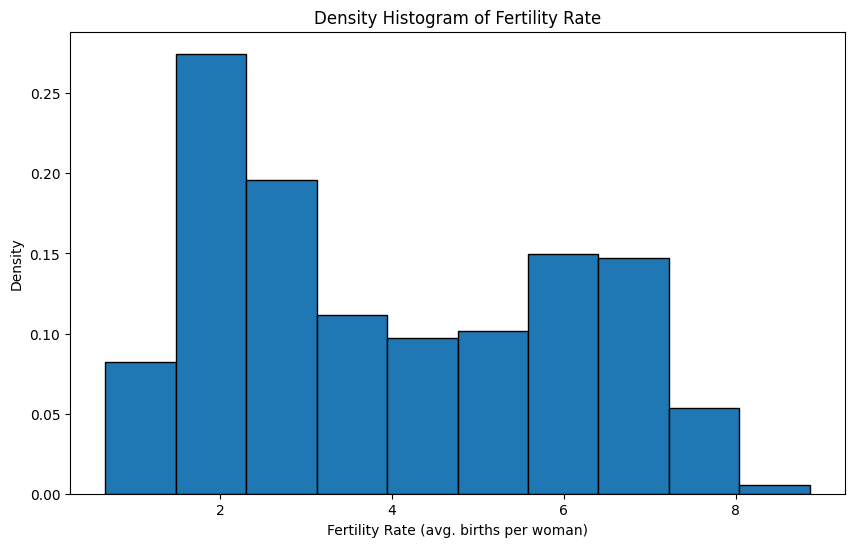

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(fertility['Fertility Rate'], density=True, edgecolor='black')
plt.title('Density Histogram of Fertility Rate')
plt.xlabel('Fertility Rate (avg. births per woman)')
plt.ylabel('Density')
plt.show()

In [7]:
merged_df = pd.merge(life_ex, poverty,
                     on=['Country','Year'], how='left')
merged_df = pd.merge(merged_df, econ_ineq,
                     on=['Country','Year'], how='left')
merged_df = pd.merge(merged_df, fertility,
                     on=['Country','Year','Code'], how='left')
merged_df = pd.merge(merged_df, sanitation,
                     on=['Country','Year'], how='left')

In [8]:
test = merged_df[['Status','Code','Life Expectancy', 'BMI', 'Extreme Poverty', 'Fertility Rate', 'Safe Sanitation']].copy()
test.dropna(inplace=True)

test.groupby('Status')[['Life Expectancy', 'BMI', 'Extreme Poverty', 'Fertility Rate', 'Safe Sanitation']].mean()

,Life Expectancy,BMI,Extreme Poverty,Fertility Rate,Safe Sanitation
Status,,,,,
Developed,79.450456,52.882067,0.605095,1.534951,83.421449
Developing,72.163525,42.873975,10.947936,2.599049,48.283926


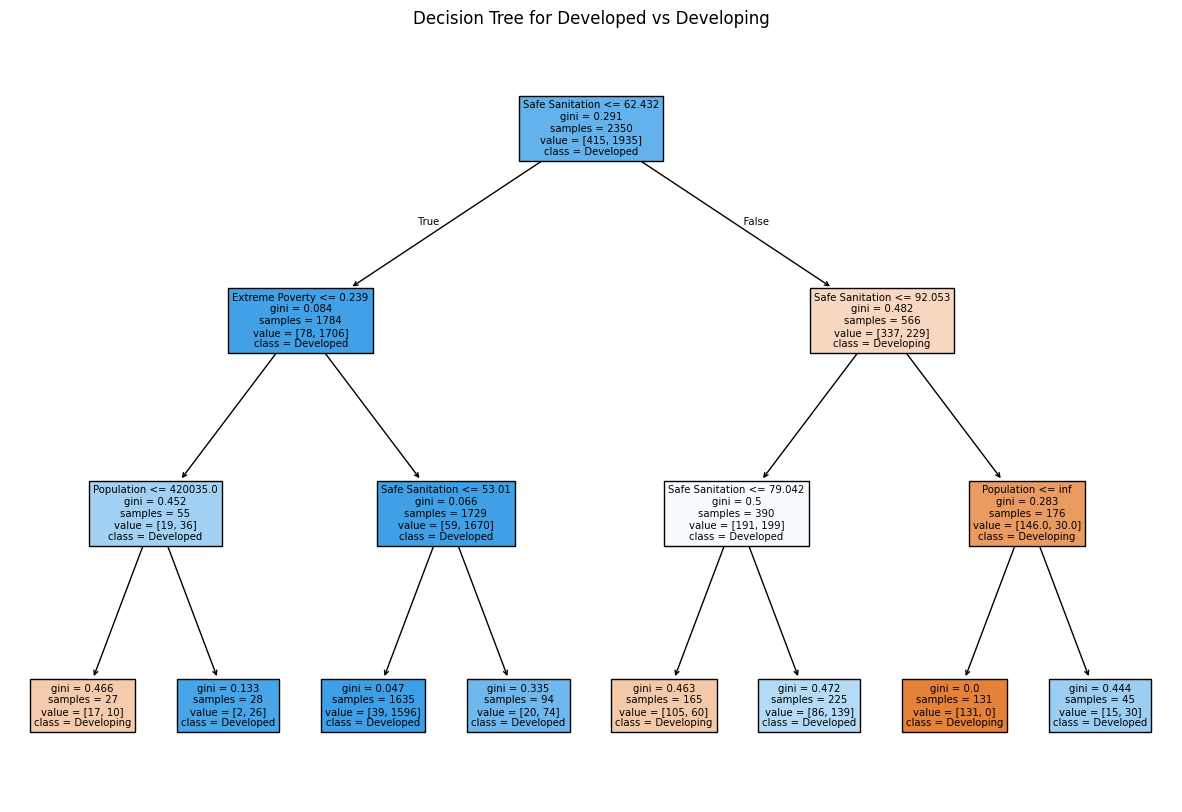

In [9]:
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier

# Prepare the data
features = ['Extreme Poverty', 'Safe Sanitation', 'Population']
X = merged_df[features]
y = merged_df['Status']

# Convert categorical features to numerical (if needed)
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42) # Limiting depth for better visualization
clf = clf.fit(X_train,y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

plt.figure(figsize=(15,10))
plot_tree(clf, filled=True, feature_names=list(X.columns), class_names=['Developing', 'Developed'])
# include title
plt.title("Decision Tree for Developed vs Developing")
plt.show()

In [10]:
merged_df = merged_df[['Country','Year','Code','Life Expectancy', 'BMI', 'Extreme Poverty', 'Fertility Rate', 'Safe Sanitation']].copy()
merged_df.dropna(inplace=True)

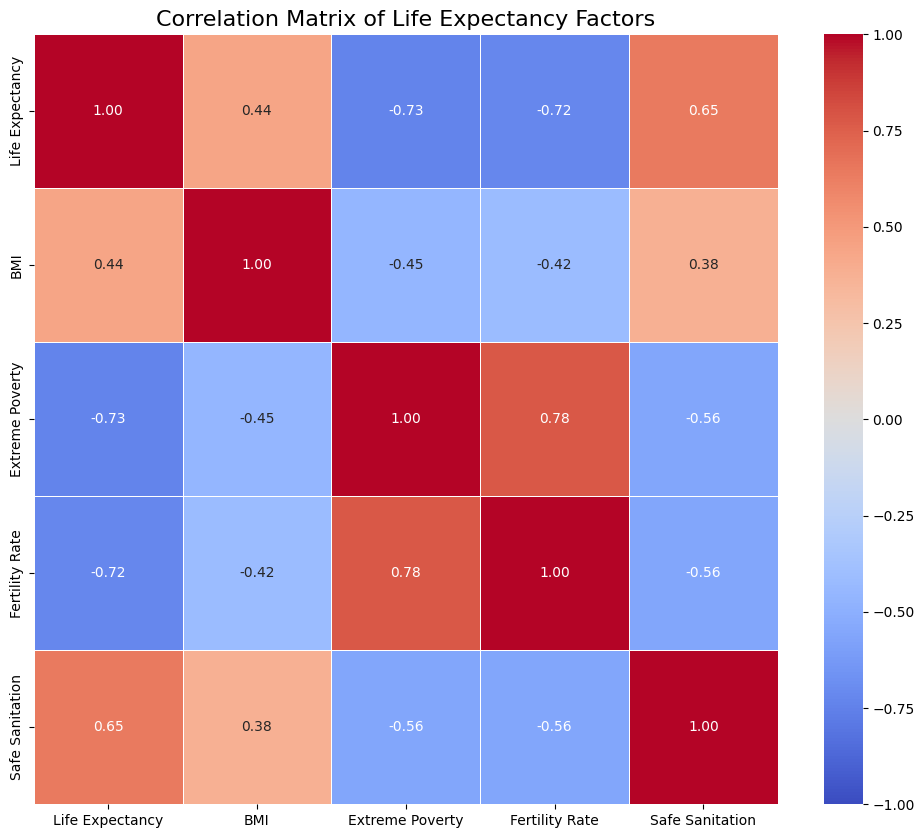

In [11]:
corr_matrix = merged_df.drop('Year', axis=1).corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Life Expectancy Factors', fontsize=16)
plt.show()

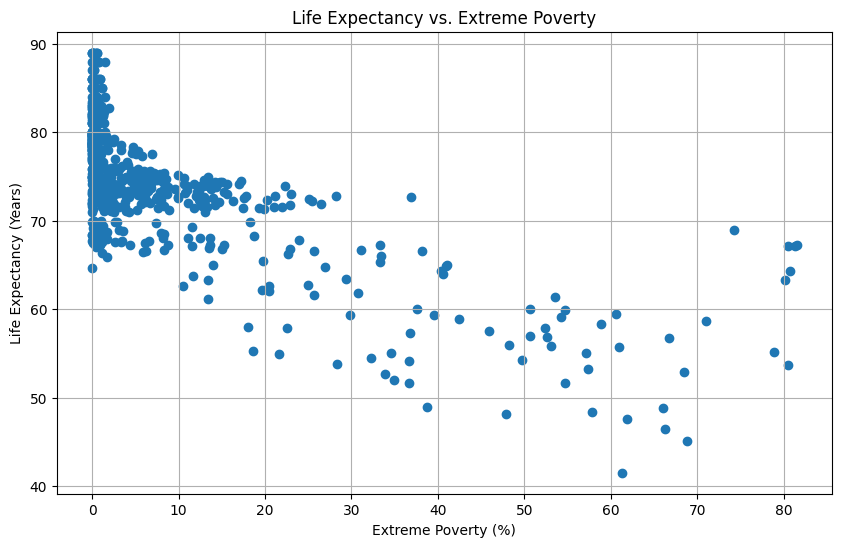

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Extreme Poverty'], merged_df['Life Expectancy'])
plt.title('Life Expectancy vs. Extreme Poverty')
plt.xlabel('Extreme Poverty (%)')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True)
plt.show()

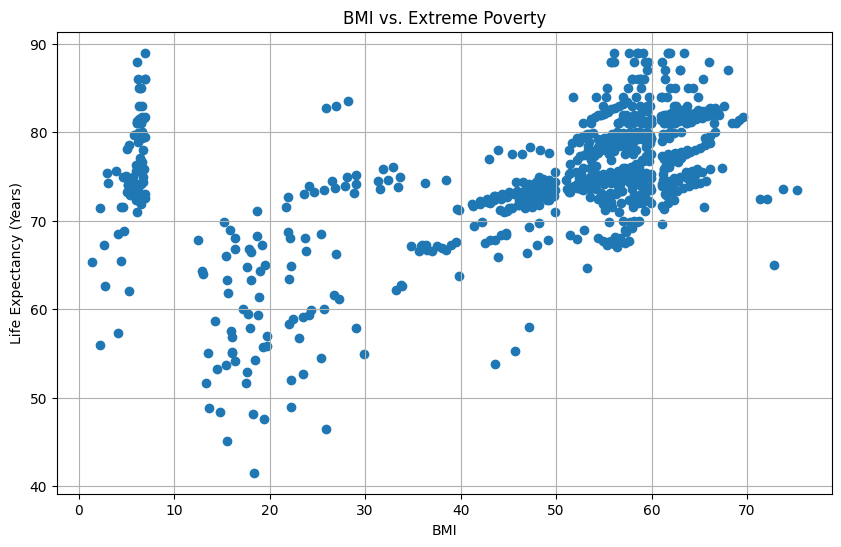

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['BMI'], merged_df['Life Expectancy'])
plt.title('BMI vs. Extreme Poverty')
plt.xlabel('BMI')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True)
plt.show()

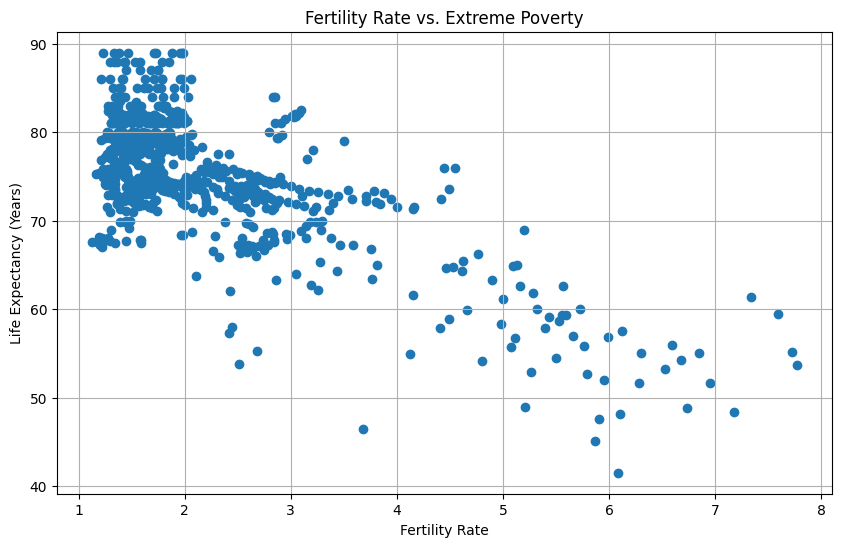

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Fertility Rate'], merged_df['Life Expectancy'])
plt.title('Fertility Rate vs. Extreme Poverty')
plt.xlabel('Fertility Rate')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True)
plt.show()

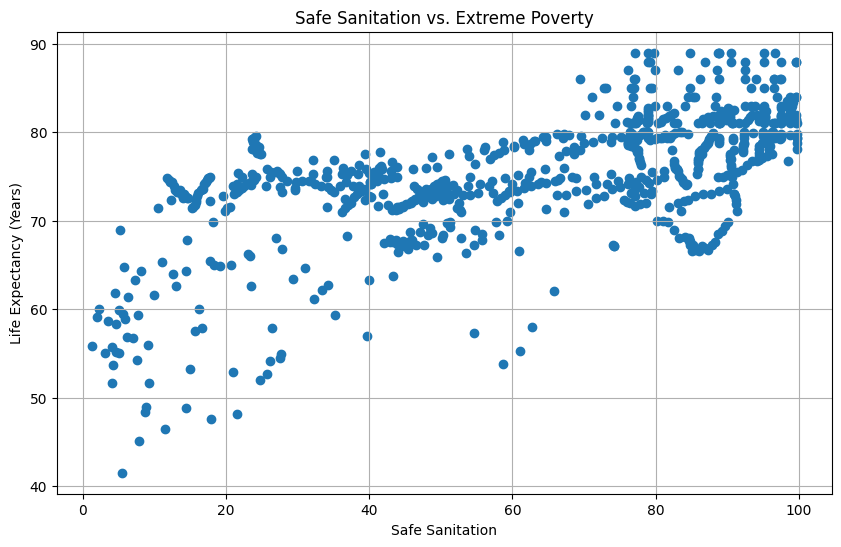

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Safe Sanitation'], merged_df['Life Expectancy'])
plt.title('Safe Sanitation vs. Extreme Poverty')
plt.xlabel('Safe Sanitation')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True)
plt.show()

## Model Building

In [16]:
X = merged_df[['BMI', 'Extreme Poverty', 'Fertility Rate', 'Safe Sanitation']]
y = merged_df['Life Expectancy']

In [17]:
# Split data into training and testing sets (recommended for evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Linear Regression
print("\n--- Linear Regression ---")
linear_model_sklearn = LinearRegression()

linear_model_sklearn.fit(X_train, y_train)
y_pred_linear = linear_model_sklearn.predict(X_test)

# Evaluate linear regression
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)
print(f"RMSE (Linear): {rmse_linear:.2f}")
print(f"R^2 (Linear): {r2_linear:.4f}")


--- Linear Regression ---
RMSE (Linear): 4.28
R^2 (Linear): 0.6608


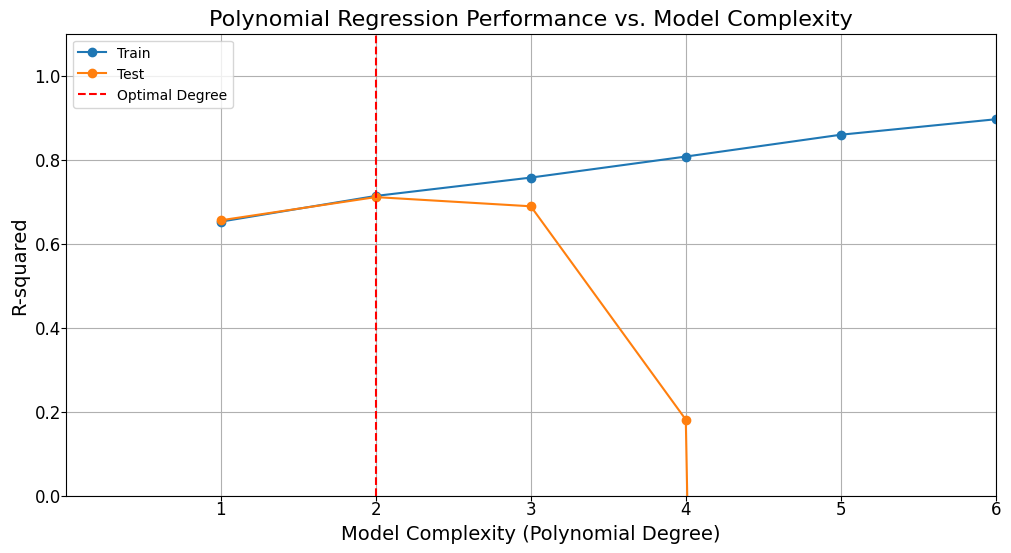

In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Experimenting with Polynomial Degrees
degrees_to_try = range(1, 11)  # Try a wider range of degrees
train_r_squared = []
test_r_squared = []

for degree in degrees_to_try:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    y_train_pred = poly_model.predict(X_train_poly)
    y_test_pred = poly_model.predict(X_test_poly)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_r_squared.append(train_r2)
    test_r_squared.append(test_r2)

# Create the visualization
plt.figure(figsize=(12, 6))
plt.plot(degrees_to_try, train_r_squared, marker='o', label='Train')
plt.plot(degrees_to_try, test_r_squared, marker='o', label='Test')

plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=14)
plt.ylabel('R-squared', fontsize=14)
plt.title('Polynomial Regression Performance vs. Model Complexity', fontsize=16)
plt.xticks(degrees_to_try)
plt.tick_params(axis='both', which='major', labelsize=12, pad=0)
plt.axvline(x=2, color='red', linestyle='--', label='Optimal Degree')
plt.grid(True)
plt.legend(loc="upper left")
plt.ylim(0, 1.1)
plt.xlim(0, 6)



plt.show()

In [19]:
# Polynomial Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_feature_names = poly.get_feature_names_out(input_features=X.columns.tolist() if hasattr(X, 'columns') else [f'feature_{i}' for i in range(X.shape[1])])

poly_model_sklearn = LinearRegression()
poly_model_sklearn.fit(X_train_poly, y_train)
y_pred_poly = poly_model_sklearn.predict(X_test_poly)

# Evaluate polynomial regression
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)
print(f"RMSE: {rmse_poly:.2f}")
print(f"R^2: {r2_poly:.4f}")

RMSE: 3.86
R^2: 0.7107


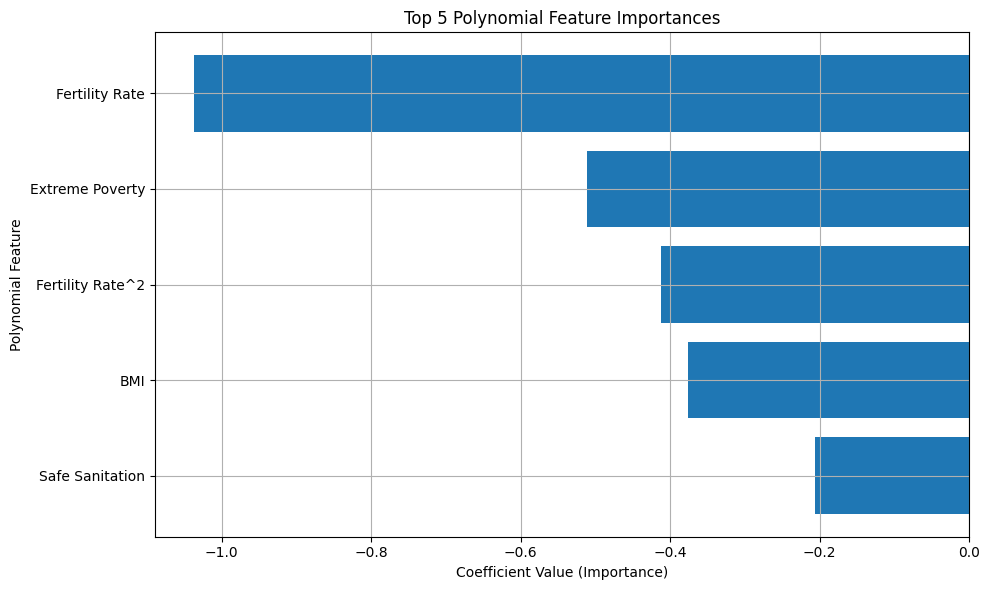

In [20]:
coefficients = poly_model_sklearn.coef_

# Create a dictionary of feature importances
importance_dict = dict(zip(poly_feature_names, coefficients))

# Visualize the top N most important polynomial features
top_n = 5  # Adjust as needed
sorted_importance = sorted(importance_dict.items(), key=lambda item: abs(item[1]), reverse=True)
top_importance = sorted_importance[:top_n]

features = [item[0] for item in top_importance]
importances = [item[1] for item in top_importance]

plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='tab:blue')
plt.xlabel('Coefficient Value (Importance)')
plt.ylabel('Polynomial Feature')
plt.title(f'Top {top_n} Polynomial Feature Importances')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

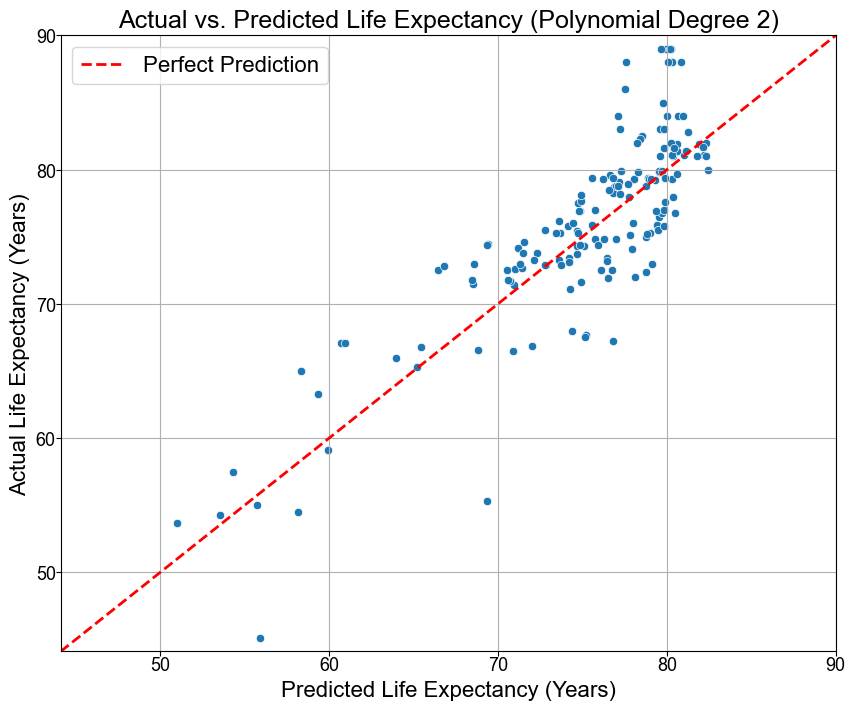

In [21]:
# Determine the minimum and maximum values across both actual and predicted
min_val = min(np.min(y_test), np.min(y_pred_poly)) - 1
max_val = max(np.max(y_test), np.max(y_pred_poly)) + 1

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_pred_poly, y=y_test)
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Predicted Life Expectancy (Years)', fontsize=16)
plt.ylabel('Actual Life Expectancy (Years)', fontsize=16)
plt.title('Actual vs. Predicted Life Expectancy (Polynomial Degree 2)', fontsize=18)
plt.legend(fontsize=16)
plt.grid(True)
sns.set_style("whitegrid")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.tick_params(axis='both', which='major', labelsize=13, pad=0)
plt.show()